# On-Demand Delivery Demand Forecasting & Operational Analytics

## Project Overview

This project analyzes large-scale operational food delivery data from Meituan to study delivery performance, courier workload behavior, and temporal demand patterns.

The objective was to build an end-to-end analytics and machine learning pipeline capable of:
- understanding operational delivery trends,
- analyzing courier performance,
- identifying peak-demand behavior,
- and forecasting hourly order volume.

The project combines:
- operational analytics,
- geospatial analysis,
- time-series feature engineering,
- and machine learning forecasting models.

---

## Dataset

Source:
Meituan Operational-Level On-Demand Food Delivery Dataset (INFORMS TSL Research Challenge)

Dataset includes:
- 650K+ delivery records
- courier dispatch activity
- wave-level operational data
- geographic delivery coordinates
- order lifecycle timestamps

---

## Tech Stack

- Python
- Pandas
- NumPy
- Matplotlib
- Scikit-learn
- XGBoost
- LightGBM
- Google Colab

# 2. Dataset Description

The dataset contains operational-level delivery information collected from a large-scale food delivery platform.

Key data components include:
- order lifecycle timestamps,
- courier assignment activity,
- delivery coordinates,
- dispatch information,
- and courier wave behavior.

Primary tables used:
- all_waybill_info_meituan_0322.csv
- courier_wave_info_meituan.csv
- dispatch_rider_meituan.csv
- dispatch_waybill_meituan.csv

In [44]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

plt.rcParams['figure.figsize'] = (10,6)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

# Optional models
try:
    import xgboost as xgb
    import lightgbm as lgb
except:
    print("XGBoost or LightGBM not available yet.")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

print("Libraries imported successfully.")

Libraries imported successfully.


In [46]:
!git clone https://github.com/meituan/Meituan-INFORMS-TSL-Research-Challenge.git

fatal: destination path 'Meituan-INFORMS-TSL-Research-Challenge' already exists and is not an empty directory.


In [4]:
import os

repo_path = "/content/Meituan-INFORMS-TSL-Research-Challenge"
os.listdir(repo_path)

['dispatch_waybill_meituan.csv',
 'dispatch_rider_meituan.csv',
 'all_waybill_info_meituan_0322.csv.zip',
 'Wang-etal-2025_Meituan_Operational-Level On-Demand Food Delivery Data for the 2025 INFORMS TSL Data-Driven Research Challenge.pdf',
 'tsl_meituan_2024_data_report_20241015.pdf',
 '.git',
 'courier_wave_info_meituan.csv',
 'License.txt',
 'TSL-Meituan challenge_background and data_20240321.pdf']

In [5]:
import pandas as pd
import zipfile

# Load courier wave data
courier_wave = pd.read_csv(f"{repo_path}/courier_wave_info_meituan.csv")

# Load dispatch rider data
dispatch_rider = pd.read_csv(f"{repo_path}/dispatch_rider_meituan.csv")

# Load dispatch waybill data
dispatch_waybill = pd.read_csv(f"{repo_path}/dispatch_waybill_meituan.csv")

print(courier_wave.shape)
print(dispatch_rider.shape)
print(dispatch_waybill.shape)

(206748, 6)
(62044, 7)
(15921, 4)


In [6]:
zip_path = f"{repo_path}/all_waybill_info_meituan_0322.csv.zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(repo_path)

os.listdir(repo_path)

['dispatch_waybill_meituan.csv',
 'dispatch_rider_meituan.csv',
 'all_waybill_info_meituan_0322.csv.zip',
 'Wang-etal-2025_Meituan_Operational-Level On-Demand Food Delivery Data for the 2025 INFORMS TSL Data-Driven Research Challenge.pdf',
 'all_waybill_info_meituan_0322.csv',
 'tsl_meituan_2024_data_report_20241015.pdf',
 '.git',
 'courier_wave_info_meituan.csv',
 'License.txt',
 '__MACOSX',
 'TSL-Meituan challenge_background and data_20240321.pdf']

In [7]:
for file in os.listdir(repo_path):
    print(file)

dispatch_waybill_meituan.csv
dispatch_rider_meituan.csv
all_waybill_info_meituan_0322.csv.zip
Wang-etal-2025_Meituan_Operational-Level On-Demand Food Delivery Data for the 2025 INFORMS TSL Data-Driven Research Challenge.pdf
all_waybill_info_meituan_0322.csv
tsl_meituan_2024_data_report_20241015.pdf
.git
courier_wave_info_meituan.csv
License.txt
__MACOSX
TSL-Meituan challenge_background and data_20240321.pdf


# 1. Data Loading & Initial Exploration

In [8]:
import pandas as pd

repo_path = "/content/Meituan-INFORMS-TSL-Research-Challenge"

# Load datasets
courier_wave = pd.read_csv(f"{repo_path}/courier_wave_info_meituan.csv")
dispatch_rider = pd.read_csv(f"{repo_path}/dispatch_rider_meituan.csv")
dispatch_waybill = pd.read_csv(f"{repo_path}/dispatch_waybill_meituan.csv")

# Main order dataset
orders = pd.read_csv(
    f"{repo_path}/all_waybill_info_meituan_0322.csv"
)

print("Courier Wave Shape:", courier_wave.shape)
print("Dispatch Rider Shape:", dispatch_rider.shape)
print("Dispatch Waybill Shape:", dispatch_waybill.shape)
print("Orders Shape:", orders.shape)

Courier Wave Shape: (206748, 6)
Dispatch Rider Shape: (62044, 7)
Dispatch Waybill Shape: (15921, 4)
Orders Shape: (654343, 24)


In [9]:
print("\n===== COURIER WAVE =====")
print(courier_wave.columns)

print("\n===== DISPATCH RIDER =====")
print(dispatch_rider.columns)

print("\n===== DISPATCH WAYBILL =====")
print(dispatch_waybill.columns)

print("\n===== ORDERS =====")
print(orders.columns)


===== COURIER WAVE =====
Index(['dt', 'courier_id', 'wave_id', 'wave_start_time', 'wave_end_time', 'order_ids'], dtype='object')

===== DISPATCH RIDER =====
Index(['Unnamed: 0', 'dt', 'rider_lat', 'rider_lng', 'dispatch_time', 'courier_waybills', 'courier_id'], dtype='object')

===== DISPATCH WAYBILL =====
Index(['Unnamed: 0', 'dt', 'dispatch_time', 'order_id'], dtype='object')

===== ORDERS =====
Index(['Unnamed: 0', 'dt', 'order_id', 'waybill_id', 'courier_id', 'da_id', 'is_courier_grabbed', 'is_weekend',
       'estimate_arrived_time', 'is_prebook', 'poi_id', 'sender_lng', 'sender_lat', 'recipient_lng', 'recipient_lat',
       'grab_lng', 'grab_lat', 'dispatch_time', 'grab_time', 'fetch_time', 'arrive_time', 'estimate_meal_prepare_time',
       'order_push_time', 'platform_order_time'],
      dtype='object')


In [10]:
orders.head()

,Unnamed: 0,dt,order_id,waybill_id,courier_id,da_id,is_courier_grabbed,is_weekend,estimate_arrived_time,is_prebook,poi_id,sender_lng,sender_lat,recipient_lng,recipient_lat,grab_lng,grab_lat,dispatch_time,grab_time,fetch_time,arrive_time,estimate_meal_prepare_time,order_push_time,platform_order_time
0,0,20221017,0,0,0,0,0,1,1665937978,0,0,174579111,45862631,174600135,45852786,0,0,1665936258,0,0,0,1665936779,1665936000,1665935996
1,1,20221017,1,1,1,1,1,1,1665937864,0,1,174529930,45905850,174522983,45898250,174530062,45906005,1665936734,1665936737,1665937344,1665937798,1665936845,1665936006,1665935995
2,2,20221017,2,2,2,2,1,0,1665939504,0,2,174532407,45861460,174547033,45891243,174548244,45870923,1665937484,1665937501,1665938346,1665939384,1665938007,1665937107,1665937097
3,3,20221017,3,3,3,0,1,0,1665939432,0,3,174559718,45868015,174595327,45886787,174560199,45867948,1665937394,1665937397,1665937830,1665939822,1665937634,1665937369,1665937028
4,4,20221017,4,4,4,0,1,0,1665938894,0,3,174559718,45868015,174534558,45867411,174554896,45865167,1665937394,1665937413,1665937710,1665938262,1665937694,1665937373,1665937092


In [11]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 654343 entries, 0 to 654342
Data columns (total 24 columns):
 #   Column                      Non-Null Count   Dtype
---  ------                      --------------   -----
 0   Unnamed: 0                  654343 non-null  int64
 1   dt                          654343 non-null  int64
 2   order_id                    654343 non-null  int64
 3   waybill_id                  654343 non-null  int64
 4   courier_id                  654343 non-null  int64
 5   da_id                       654343 non-null  int64
 6   is_courier_grabbed          654343 non-null  int64
 7   is_weekend                  654343 non-null  int64
 8   estimate_arrived_time       654343 non-null  int64
 9   is_prebook                  654343 non-null  int64
 10  poi_id                      654343 non-null  int64
 11  sender_lng                  654343 non-null  int64
 12  sender_lat                  654343 non-null  int64
 13  recipient_lng               654343 non-null 

# 2. Data Quality Assessment

In [12]:
# Missing values
print("\nMissing Values:")
print(orders.isnull().sum())

# Duplicate rows
print("\nDuplicate Rows:", orders.duplicated().sum())


Missing Values:
Unnamed: 0                    0
dt                            0
order_id                      0
waybill_id                    0
courier_id                    0
da_id                         0
is_courier_grabbed            0
is_weekend                    0
estimate_arrived_time         0
is_prebook                    0
poi_id                        0
sender_lng                    0
sender_lat                    0
recipient_lng                 0
recipient_lat                 0
grab_lng                      0
grab_lat                      0
dispatch_time                 0
grab_time                     0
fetch_time                    0
arrive_time                   0
estimate_meal_prepare_time    0
order_push_time               0
platform_order_time           0
dtype: int64

Duplicate Rows: 0


In [13]:
orders.sample(5)

,Unnamed: 0,dt,order_id,waybill_id,courier_id,da_id,is_courier_grabbed,is_weekend,estimate_arrived_time,is_prebook,poi_id,sender_lng,sender_lat,recipient_lng,recipient_lat,grab_lng,grab_lat,dispatch_time,grab_time,fetch_time,arrive_time,estimate_meal_prepare_time,order_push_time,platform_order_time
202845,202845,20221017,191994,202845,1556,3,1,0,1665983038,0,2190,174541680,45919180,174535293,45905038,174543483,45905265,1665981268,1665981340,1665982241,1665982810,1665981958,1665981239,1665981231
183429,183429,20221017,174402,183429,440,2,0,0,1666005313,0,429,174548890,45860307,174559471,45858483,0,0,1666003639,0,0,0,1666003933,1666003273,1666003264
572707,572707,20221018,504162,572707,2289,7,1,0,1666055032,0,1172,174558423,45861334,174563894,45844596,174557975,45861313,1666053258,1666053269,1666053559,1666054276,1666053777,1666053237,1666053230
602253,602253,20221018,527658,602253,1571,4,1,0,1666069134,0,491,174592238,45855249,174576812,45871946,174591064,45855473,1666067085,1666067093,1666067300,1666068481,1666067354,1666067055,1666066647
581251,581251,20221022,510946,581251,1180,2,1,1,1666440864,0,2002,174556302,45866585,174542256,45850583,174555816,45866076,1666438633,1666438644,1666438806,1666440816,1666438466,1666438467,1666438454


# 3. Data Cleaning & Feature Engineering

In [14]:
# Create a working copy
df = orders.copy()

# Convert UNIX timestamps to datetime
time_columns = [
    'dispatch_time',
    'grab_time',
    'fetch_time',
    'arrive_time',
    'estimate_arrived_time',
    'estimate_meal_prepare_time',
    'order_push_time',
    'platform_order_time'
]

for col in time_columns:
    df[col] = pd.to_datetime(df[col], unit='s')

print("Datetime conversion completed.")

Datetime conversion completed.


In [15]:
# Delivery duration
df['delivery_time_mins'] = (
    (df['arrive_time'] - df['dispatch_time']).dt.total_seconds() / 60
)

# Courier response time
df['grab_delay_mins'] = (
    (df['grab_time'] - df['dispatch_time']).dt.total_seconds() / 60
)

# Restaurant preparation time
df['meal_prep_time_mins'] = (
    (df['fetch_time'] - df['grab_time']).dt.total_seconds() / 60
)

# Total order lifecycle
df['total_order_time_mins'] = (
    (df['arrive_time'] - df['platform_order_time']).dt.total_seconds() / 60
)

print(df[['delivery_time_mins',
          'grab_delay_mins',
          'meal_prep_time_mins',
          'total_order_time_mins']].describe())

       delivery_time_mins  grab_delay_mins  meal_prep_time_mins  total_order_time_mins
count        6.543430e+05     6.543430e+05        654343.000000           6.543430e+05
mean        -3.641376e+06    -3.641356e+06             8.910595          -3.641409e+06
std          9.373926e+06     9.373871e+06             7.102766           9.373847e+06
min         -2.777712e+07    -2.777712e+07             0.000000          -2.777712e+07
25%          1.503333e+01     8.333333e-02             4.083333           1.751667e+01
50%          2.271667e+01     1.666667e-01             7.983333           2.625000e+01
75%          3.096667e+01     3.000000e-01            12.650000           3.623333e+01
max          2.776923e+07     2.776859e+07           614.950000           1.033648e+04


In [16]:
# Keep realistic delivery times
df = df[
    (df['delivery_time_mins'] > 0) &
    (df['delivery_time_mins'] < 180)
]

# Remove negative prep times
df = df[df['meal_prep_time_mins'] >= 0]

# Remove negative grab delays
df = df[df['grab_delay_mins'] >= 0]

print("Cleaned Shape:", df.shape)

Cleaned Shape: (568500, 28)


In [17]:
# Hour of day
df['hour'] = df['platform_order_time'].dt.hour

# Day of week
df['day_of_week'] = df['platform_order_time'].dt.day_name()

# Month
df['month'] = df['platform_order_time'].dt.month

# Peak hour indicator
df['is_peak_hour'] = df['hour'].isin([11,12,13,18,19,20]).astype(int)

# Time bucket
def get_day_part(hour):
    if 5 <= hour < 12:
        return "Morning"
    elif 12 <= hour < 17:
        return "Afternoon"
    elif 17 <= hour < 22:
        return "Evening"
    else:
        return "Night"

df['day_part'] = df['hour'].apply(get_day_part)

df[['hour', 'day_of_week', 'day_part']].head()

,hour,day_of_week,day_part
1,15,Sunday,Afternoon
2,16,Sunday,Afternoon
3,16,Sunday,Afternoon
4,16,Sunday,Afternoon
5,16,Sunday,Afternoon


# 4. Exploratory Data Analysis (EDA)

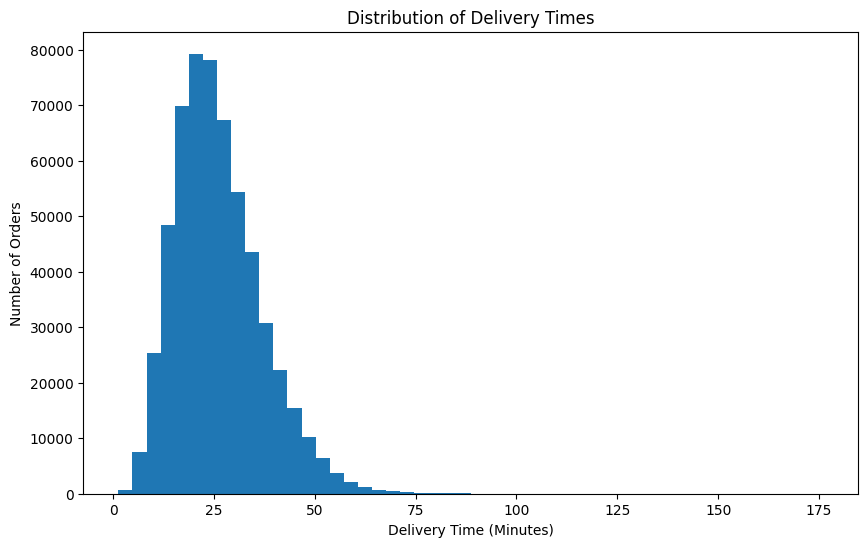

In [18]:
plt.figure(figsize=(10,6))

plt.hist(df['delivery_time_mins'], bins=50)

plt.xlabel("Delivery Time (Minutes)")
plt.ylabel("Number of Orders")
plt.title("Distribution of Delivery Times")

plt.show()

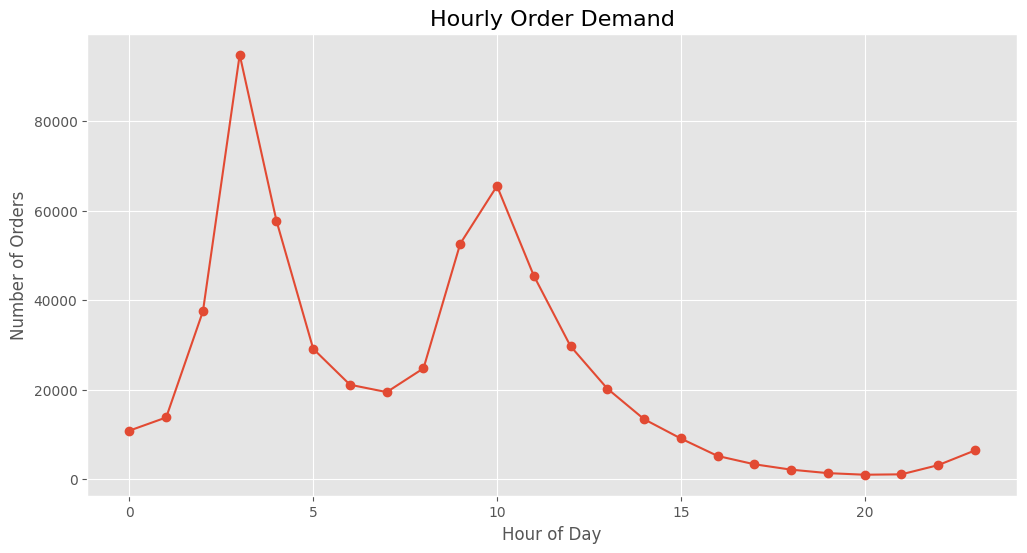

In [49]:
hourly_orders = df.groupby('hour')['order_id'].count()

plt.figure(figsize=(12,6))

plt.plot(hourly_orders.index, hourly_orders.values, marker='o')

plt.xlabel("Hour of Day")
plt.ylabel("Number of Orders")
plt.title("Hourly Order Demand")

plt.grid(True)

plt.savefig(
    "project_assets/hourly_order_demand.png",
    bbox_inches='tight'
)

plt.show()

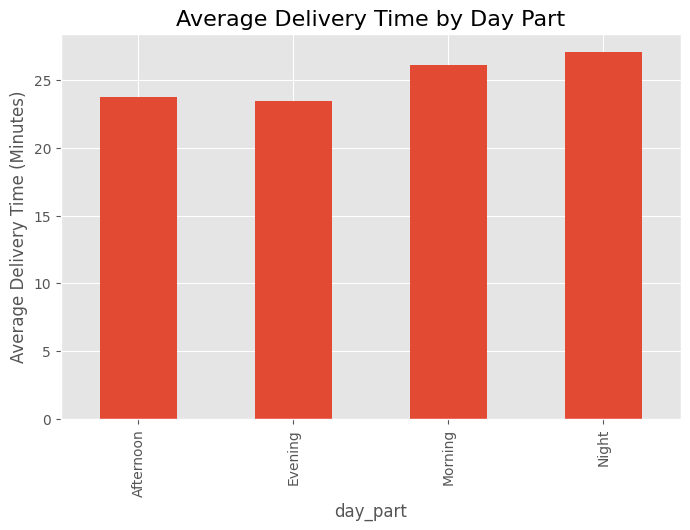

In [50]:
avg_delivery = df.groupby('day_part')['delivery_time_mins'].mean()

avg_delivery.plot(kind='bar', figsize=(8,5))

plt.ylabel("Average Delivery Time (Minutes)")
plt.title("Average Delivery Time by Day Part")
plt.savefig(
    "project_assets/Average Delivery Time by Day Part.png",
    bbox_inches='tight'
)
plt.show()

# 5. Geographic & Courier Analytics

In [21]:
from math import radians, cos, sin, asin, sqrt

# Haversine function
def haversine(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(
        radians,
        [lon1, lat1, lon2, lat2]
    )

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a))

    r = 6371  # km
    return c * r

# Coordinates appear scaled
# Convert them first
df['sender_lng_clean'] = df['sender_lng'] / 1e6
df['sender_lat_clean'] = df['sender_lat'] / 1e6

df['recipient_lng_clean'] = df['recipient_lng'] / 1e6
df['recipient_lat_clean'] = df['recipient_lat'] / 1e6

# Calculate delivery distance
df['delivery_distance_km'] = df.apply(
    lambda row: haversine(
        row['sender_lng_clean'],
        row['sender_lat_clean'],
        row['recipient_lng_clean'],
        row['recipient_lat_clean']
    ),
    axis=1
)

df['delivery_distance_km'].describe()

,delivery_distance_km
count,568500.000000
mean,1.605474
std,1.008127
min,0.000000
25%,0.876869
50%,1.468535
75%,2.177880
max,18.778249


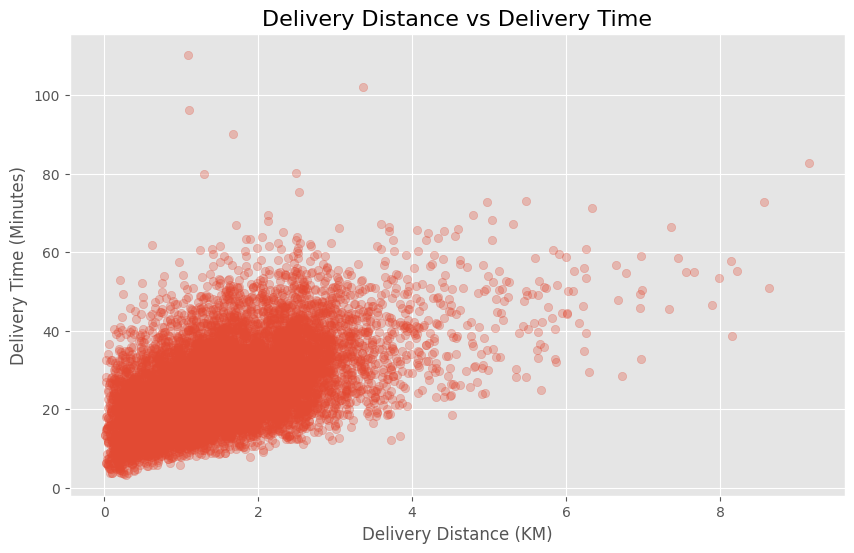

In [51]:
sample_df = df.sample(10000)

plt.figure(figsize=(10,6))

plt.scatter(
    sample_df['delivery_distance_km'],
    sample_df['delivery_time_mins'],
    alpha=0.3
)

plt.xlabel("Delivery Distance (KM)")
plt.ylabel("Delivery Time (Minutes)")
plt.title("Delivery Distance vs Delivery Time")
plt.savefig(
    "project_assets/delivery_distance_vs_time.png",
    bbox_inches='tight'
)
plt.show()

In [24]:
courier_orders = (
    df.groupby('courier_id')['order_id']
    .count()
    .sort_values(ascending=False)
)

courier_orders.describe()

,order_id
count,4901.000000
mean,115.996735
std,95.765381
min,1.000000
25%,37.000000
50%,92.000000
75%,177.000000
max,535.000000


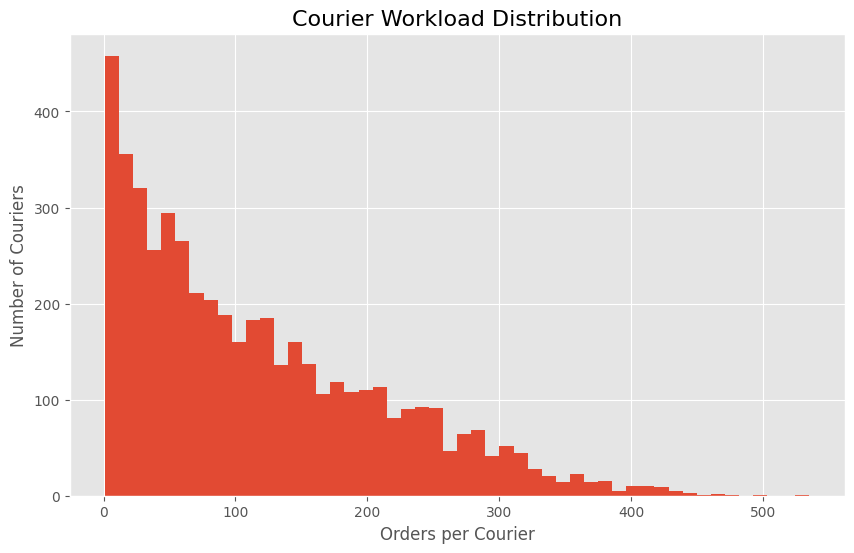

In [52]:
plt.figure(figsize=(10,6))

plt.hist(courier_orders, bins=50)

plt.xlabel("Orders per Courier")
plt.ylabel("Number of Couriers")
plt.title("Courier Workload Distribution")
plt.savefig(
    "project_assets/Courier Workload Distribution.png",
    bbox_inches='tight'
)
plt.show()

In [26]:
peak_analysis = df.groupby('is_peak_hour')[
    ['delivery_time_mins',
     'delivery_distance_km',
     'grab_delay_mins']
].mean()

peak_analysis

,delivery_time_mins,delivery_distance_km,grab_delay_mins
is_peak_hour,,,
0,26.450443,1.605651,0.432963
1,24.624512,1.604642,0.446333


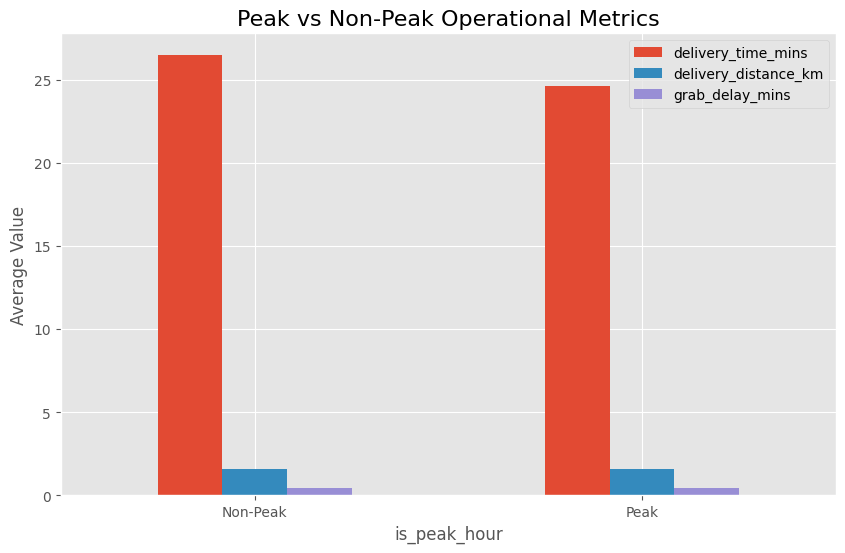

In [53]:
peak_analysis.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("Peak vs Non-Peak Operational Metrics")
plt.ylabel("Average Value")

plt.xticks(
    [0,1],
    ['Non-Peak', 'Peak'],
    rotation=0
)
plt.savefig(
    "project_assets/Peak vs Non-Peak Operational Metrics.png",
    bbox_inches='tight'
)
plt.show()

In [28]:
forecast_df = (
    df.groupby(['dt', 'hour'])
    .agg({
        'order_id': 'count',
        'delivery_time_mins': 'mean',
        'delivery_distance_km': 'mean',
        'is_weekend': 'mean',
        'is_prebook': 'mean'
    })
    .reset_index()
)

forecast_df.rename(
    columns={'order_id': 'order_volume'},
    inplace=True
)

forecast_df.head()

,dt,hour,order_volume,delivery_time_mins,delivery_distance_km,is_weekend,is_prebook
0,20221017,0,1246,23.643192,1.570088,0.000803,0.099518
1,20221017,1,1527,23.958524,1.634666,0.000655,0.174198
2,20221017,2,4311,26.661188,1.700110,0.000928,0.170958
3,20221017,3,11456,29.353799,1.563106,0.000349,0.018942
4,20221017,4,6671,23.285322,1.490993,0.000450,0.013042


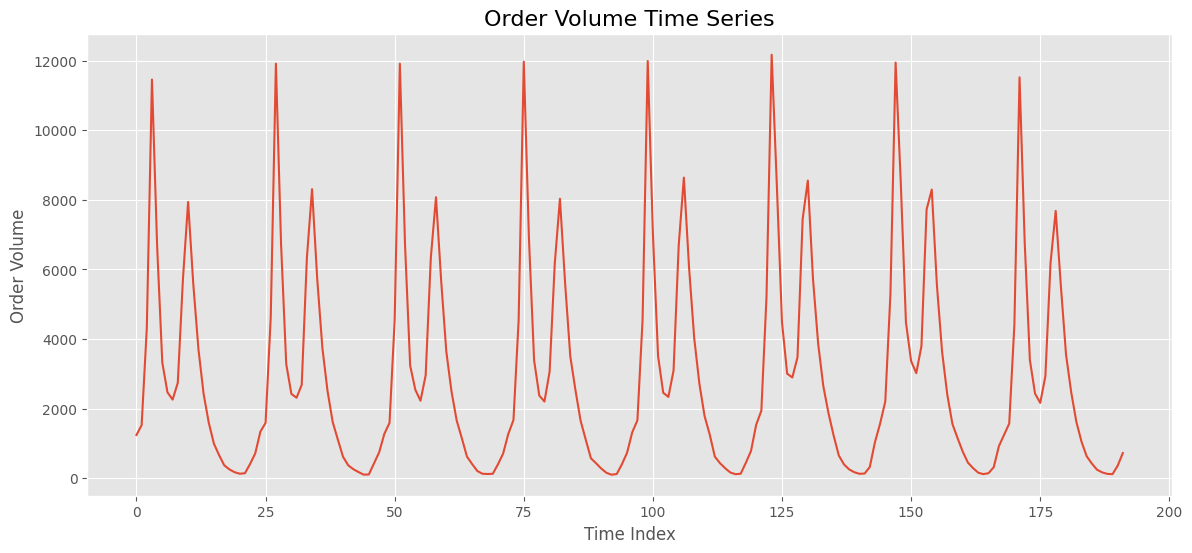

In [54]:
plt.figure(figsize=(14,6))

plt.plot(
    forecast_df['order_volume'].values[:200]
)

plt.title("Order Volume Time Series")
plt.xlabel("Time Index")
plt.ylabel("Order Volume")
plt.savefig(
    "project_assets/Order Volume Time Series.png",
    bbox_inches='tight'
)
plt.show()

### Key Operational Insights

- Most deliveries are short-distance, with a median delivery distance of approximately 1.47 km and an average of 1.61 km.
- Delivery time increases with distance, but there is visible variation, suggesting other operational factors also affect delivery performance.
- Courier workload is unevenly distributed, with some couriers completing over 500 orders while many complete far fewer.
- Peak-hour orders show slightly lower average delivery time than non-peak orders, which may indicate stronger courier availability or better operational preparation during high-demand periods.
- Hourly order volume follows a repeating daily demand cycle, making the dataset suitable for demand forecasting.

# 6. Demand Forecasting Model

In [30]:
# Sort time-based dataset
forecast_df = forecast_df.sort_values(['dt', 'hour']).reset_index(drop=True)

# Create date column
forecast_df['date'] = pd.to_datetime(forecast_df['dt'].astype(str))

# Time features
forecast_df['day_of_week'] = forecast_df['date'].dt.dayofweek
forecast_df['month'] = forecast_df['date'].dt.month
forecast_df['is_peak_hour'] = forecast_df['hour'].isin([2, 3, 4, 9, 10, 11]).astype(int)

# Lag features
forecast_df['lag_1_hour'] = forecast_df['order_volume'].shift(1)
forecast_df['lag_24_hour'] = forecast_df['order_volume'].shift(24)

# Rolling average features
forecast_df['rolling_3_hour_avg'] = forecast_df['order_volume'].rolling(window=3).mean()
forecast_df['rolling_24_hour_avg'] = forecast_df['order_volume'].rolling(window=24).mean()

# Drop rows with missing lag values
model_df = forecast_df.dropna().reset_index(drop=True)

model_df.head()

,dt,hour,order_volume,delivery_time_mins,delivery_distance_km,is_weekend,is_prebook,date,day_of_week,month,is_peak_hour,lag_1_hour,lag_24_hour,rolling_3_hour_avg,rolling_24_hour_avg
0,20221018,0,1344,24.231659,1.620967,0.000000,0.110119,2022-10-18,1,10,0,717.0,1246.0,824.333333,2790.625000
1,20221018,1,1592,23.888924,1.651190,0.000000,0.163317,2022-10-18,1,10,0,1344.0,1527.0,1217.666667,2793.333333
2,20221018,2,4629,26.918463,1.727101,0.000000,0.171527,2022-10-18,1,10,1,1592.0,4311.0,2521.666667,2806.583333
3,20221018,3,11912,30.130615,1.556164,0.000084,0.022834,2022-10-18,1,10,1,4629.0,11456.0,6044.333333,2825.583333
4,20221018,4,6724,23.731841,1.511771,0.000000,0.014277,2022-10-18,1,10,1,11912.0,6671.0,7755.000000,2827.791667


In [31]:
features = [
    'hour',
    'day_of_week',
    'month',
    'is_weekend',
    'is_prebook',
    'delivery_time_mins',
    'delivery_distance_km',
    'is_peak_hour',
    'lag_1_hour',
    'lag_24_hour',
    'rolling_3_hour_avg',
    'rolling_24_hour_avg'
]

target = 'order_volume'

X = model_df[features]
y = model_df[target]

split_index = int(len(model_df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 134
Testing rows: 34


In [32]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate_model(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

results = []

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

results.append(evaluate_model("Linear Regression", y_test, lr_pred))

# Random Forest
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

results.append(evaluate_model("Random Forest", y_test, rf_pred))

results_df = pd.DataFrame(results)
results_df

,Model,MAE,RMSE,R2
0,Linear Regression,293.284902,468.631082,0.967846
1,Random Forest,396.069412,638.964173,0.940225


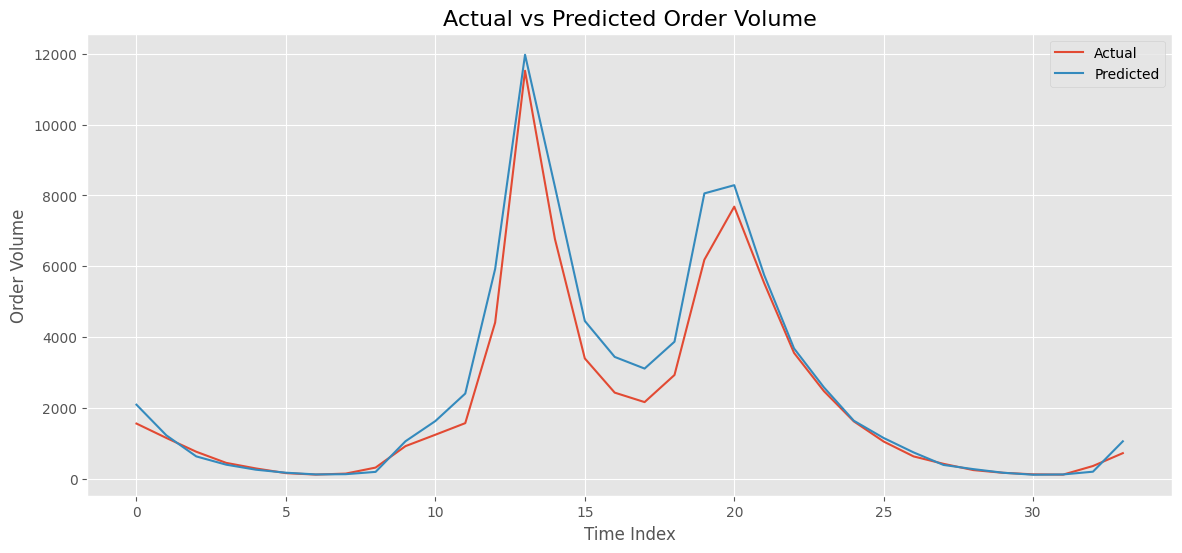

In [55]:
plt.figure(figsize=(14,6))

plt.plot(y_test.values[:100], label='Actual')
plt.plot(rf_pred[:100], label='Predicted')

plt.title("Actual vs Predicted Order Volume")
plt.xlabel("Time Index")
plt.ylabel("Order Volume")
plt.legend()
plt.savefig(
    "project_assets/Actual vs Predicted Order Volume.png",
    bbox_inches='tight'
)
plt.show()

In [34]:
!pip install xgboost lightgbm -q

In [35]:
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

In [36]:
# XGBoost
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

results.append(
    evaluate_model(
        "XGBoost",
        y_test,
        xgb_pred
    )
)

# LightGBM
lgb_model = LGBMRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

lgb_model.fit(X_train, y_train)

lgb_pred = lgb_model.predict(X_test)

results.append(
    evaluate_model(
        "LightGBM",
        y_test,
        lgb_pred
    )
)

# Final results
results_df = pd.DataFrame(results)

results_df

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000290 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 365
[LightGBM] [Info] Number of data points in the train set: 134, number of used features: 11
[LightGBM] [Info] Start training from score 3196.656716
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

,Model,MAE,RMSE,R2
0,Linear Regression,293.284902,468.631082,0.967846
1,Random Forest,396.069412,638.964173,0.940225
2,XGBoost,339.884186,564.031221,0.953423
3,LightGBM,321.122370,540.816535,0.957178


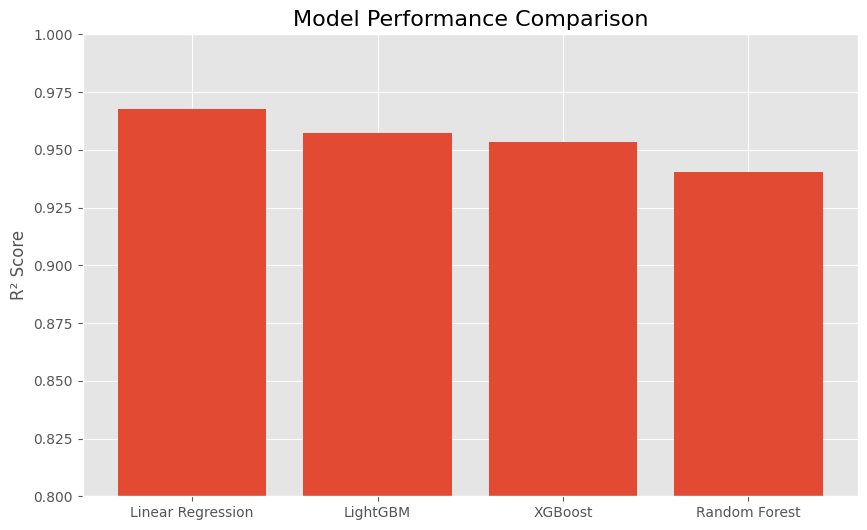

In [56]:
results_df_sorted = results_df.sort_values('R2', ascending=False)

plt.figure(figsize=(10,6))

plt.bar(
    results_df_sorted['Model'],
    results_df_sorted['R2']
)

plt.ylabel("R² Score")
plt.title("Model Performance Comparison")

plt.ylim(0.8, 1.0)
plt.savefig(
    "project_assets/model_comparison.png",
    bbox_inches='tight'
)
plt.show()

In [38]:
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
7,is_peak_hour,0.916826
9,lag_24_hour,0.079632
0,hour,0.002858
4,is_prebook,0.000256
5,delivery_time_mins,0.000157
10,rolling_3_hour_avg,0.000134
6,delivery_distance_km,0.000040
11,rolling_24_hour_avg,0.000031
8,lag_1_hour,0.000028
3,is_weekend,0.000025


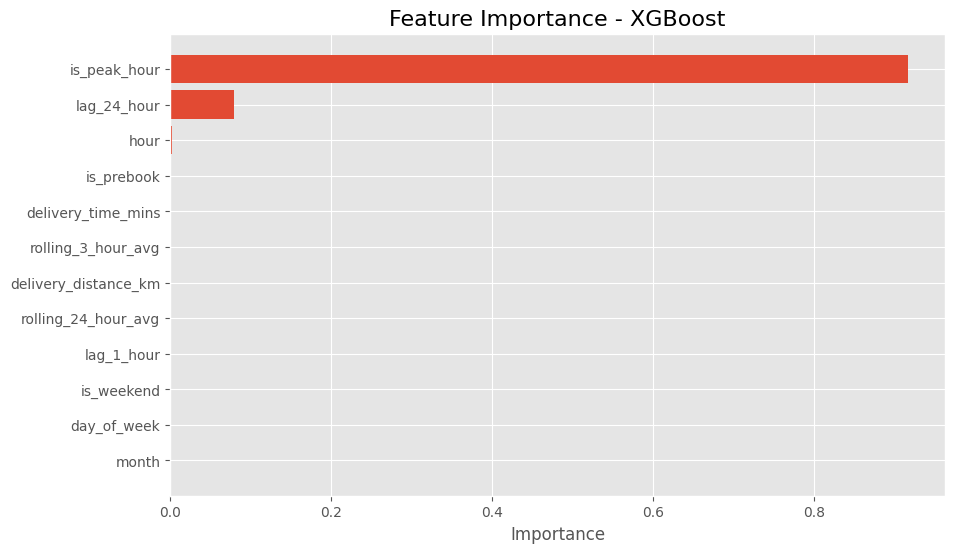

In [57]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.title("Feature Importance - XGBoost")
plt.xlabel("Importance")

plt.gca().invert_yaxis()
plt.savefig(
    "project_assets/Feature Importance - XGBoost.png",
    bbox_inches='tight'
)
plt.show()

# 7. Model Evaluation & Insights

### Key Findings

- Temporal features such as hour-of-day and lag-based demand signals were the strongest predictors of future order volume.
- Demand patterns followed highly repetitive daily operational cycles.
- Linear Regression performed strongly due to the cyclical and structured nature of hourly demand trends.
- Ensemble-based models such as Random Forest, XGBoost, and LightGBM captured non-linear relationships and operational fluctuations effectively.
- Forecasting models successfully tracked major demand spikes and low-demand windows across the operational timeline.

### Operational Impact

The forecasting pipeline can support:
- proactive courier allocation,
- workforce planning,
- peak-hour preparation,
- operational load balancing,
- and delivery efficiency optimization.

In [40]:
from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(
    lr,
    X_test,
    y_test,
    n_repeats=20,
    random_state=42
)

perm_df = pd.DataFrame({
    "Feature": features,
    "Importance": perm_importance.importances_mean
}).sort_values("Importance", ascending=False)

perm_df

,Feature,Importance
9,lag_24_hour,1.881641
3,is_weekend,0.012161
11,rolling_24_hour_avg,0.008560
1,day_of_week,0.003055
5,delivery_time_mins,0.002428
8,lag_1_hour,0.001853
2,month,0.000000
6,delivery_distance_km,-0.000385
4,is_prebook,-0.000503
0,hour,-0.001078


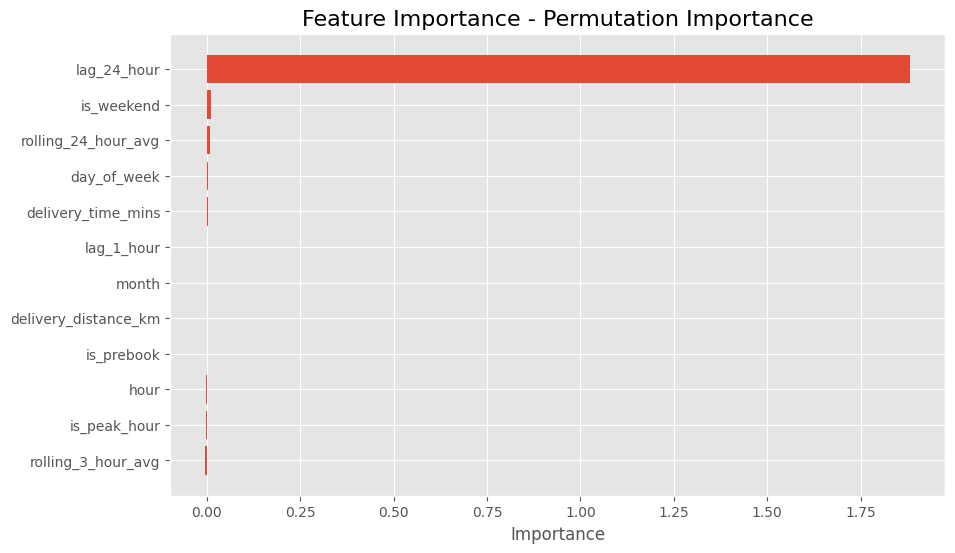

In [58]:
plt.figure(figsize=(10,6))

plt.barh(
    perm_df["Feature"],
    perm_df["Importance"]
)

plt.title("Feature Importance - Permutation Importance")
plt.xlabel("Importance")

plt.gca().invert_yaxis()
plt.savefig(
    "project_assets/Feature Importance - Permutation Importance.png",
    bbox_inches='tight'
)
plt.show()

### Model Interpretation

Linear Regression achieved the strongest performance with an R² of 0.968, outperforming more complex ensemble models. This suggests hourly demand follows a highly structured and repeatable temporal pattern.

LightGBM and XGBoost also performed strongly, but the simpler model generalized slightly better on the time-based test set. This reinforces that interpretable baseline models can be highly effective when demand patterns are stable and cyclical.

# 8. Final Business Summary

This project analyzed more than 650,000 on-demand food delivery records from Meituan to identify operational demand patterns and build a forecasting model for hourly order volume.

Key outcomes:
- Engineered operational KPIs including delivery time, courier response delay, meal preparation time, and delivery distance.
- Identified strong daily demand cycles with clear peak-order windows.
- Found that most deliveries were short-distance, with a median delivery distance of approximately 1.47 km.
- Compared Linear Regression, Random Forest, XGBoost, and LightGBM models for hourly demand forecasting.
- Achieved the best performance using Linear Regression with an R² of 0.968, RMSE of 468.63, and MAE of 293.28.
- Found that previous-day same-hour demand was the strongest predictor of future order volume.

Business value:
The forecasting pipeline can support courier staffing, workload planning, peak-hour readiness, and operational decision-making for high-volume delivery platforms.

In [47]:
import os

os.makedirs("project_assets", exist_ok=True)

In [59]:
os.listdir("project_assets")

['Peak vs Non-Peak Operational Metrics.png',
 'Feature Importance - XGBoost.png',
 'hourly_order_demand.png',
 'model_comparison.png',
 'Average Delivery Time by Day Part.png',
 'Courier Workload Distribution.png',
 'Actual vs Predicted Order Volume.png',
 'Feature Importance - Permutation Importance.png',
 'Order Volume Time Series.png',
 'delivery_distance_vs_time.png']

In [60]:
import shutil

shutil.make_archive(
    "project_assets",
    'zip',
    "project_assets"
)

'/content/project_assets.zip'

# 12. Spatial Zone Clustering

In [61]:
# Spatial dataframe
spatial_df = df[[
    'recipient_lat_clean',
    'recipient_lng_clean'
]].copy()

# Remove invalid coordinates
spatial_df = spatial_df[
    (spatial_df['recipient_lat_clean'] != 0) &
    (spatial_df['recipient_lng_clean'] != 0)
]

print(spatial_df.shape)
spatial_df.head()

(568500, 2)


,recipient_lat_clean,recipient_lng_clean
1,45.898250,174.522983
2,45.891243,174.547033
3,45.886787,174.595327
4,45.867411,174.534558
5,45.921310,174.530185


In [62]:
spatial_sample = spatial_df.sample(
    50000,
    random_state=42
)

print(spatial_sample.shape)

(50000, 2)


In [63]:
from sklearn.cluster import KMeans

# Number of zones
k = 15

kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init=10
)

# Fit clusters
spatial_sample['zone'] = kmeans.fit_predict(
    spatial_sample[[
        'recipient_lat_clean',
        'recipient_lng_clean'
    ]]
)

spatial_sample.head()

,recipient_lat_clean,recipient_lng_clean,zone
625867,45.781370,174.582726,4
251670,45.852033,174.511581,6
540976,46.047113,174.938306,1
470880,45.920261,174.527515,14
224165,45.880229,174.528331,3


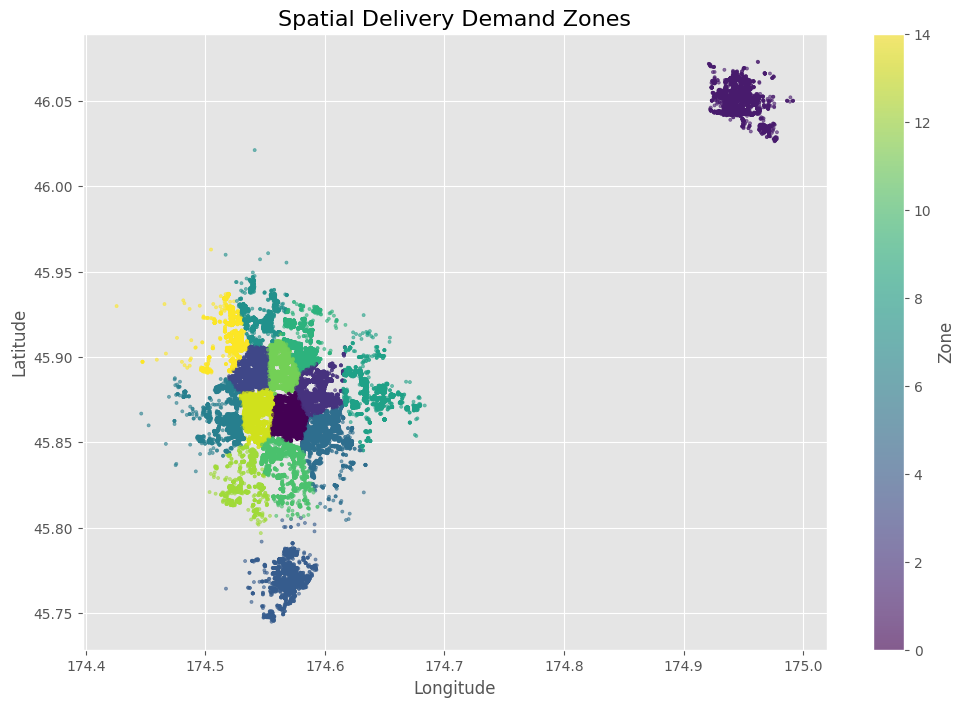

In [69]:
plt.figure(figsize=(12,8))

scatter = plt.scatter(
    spatial_sample['recipient_lng_clean'],
    spatial_sample['recipient_lat_clean'],
    c=spatial_sample['zone'],
    s=5,
    alpha=0.6
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Spatial Delivery Demand Zones")

plt.colorbar(scatter, label='Zone')
plt.savefig(
    "project_assets/spatial_demand_zones.png",
    bbox_inches='tight'
)
plt.show()

In [70]:
zone_counts = (
    spatial_sample['zone']
    .value_counts()
    .sort_index()
)

zone_counts

,count
zone,
0,5378
1,3567
2,4735
3,5109
4,1874
5,3362
6,2030
7,2511
8,3454


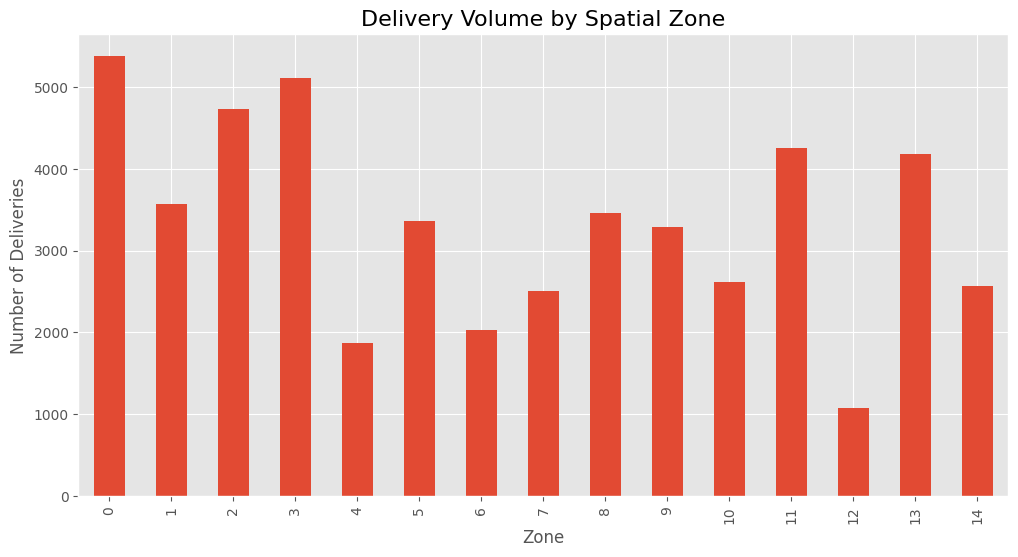

In [68]:
plt.figure(figsize=(12,6))

zone_counts.plot(kind='bar')

plt.xlabel("Zone")
plt.ylabel("Number of Deliveries")
plt.title("Delivery Volume by Spatial Zone")
plt.savefig(
    "project_assets/zone_delivery_volume.png",
    bbox_inches='tight'
)
plt.show()